In [2]:
!pip install pytorch-msssim --no-deps --quiet
#imports
import torch, pickle, copy, torchvision, torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.optim import lr_scheduler
from pytorch_msssim import ssim
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [3]:
#encoder architecture

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.Flt = nn.Flatten()
        
        #branch 1
        self.L1_1 = nn.Linear(784, 512)
        self.L2_1 = nn.Linear(512, 128)

        #brach 2
        self.L1_2 = nn.Linear(784, 256)
        self.L2_2 = nn.Linear(256, 64)

        self.L1 = nn.Linear(192, 64)

        self.gelu = nn.GELU()
    
    def forward(self, img):
        
        out = self.Flt(img)
        
        #branch 1
        out1 = out
        out1 = self.gelu(self.L1_1(out1))
        out1 = self.gelu(self.L2_1(out1))

        #branch 2
        out2 = out
        out2 = self.gelu(self.L1_2(out2))
        out2 = self.gelu(self.L2_2(out2))

        #concat
        out = torch.cat((out1, out2), dim=1)
        
        out = self.gelu(self.L1(out))

        return out
#decoder architecture

class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.Exp = nn.Linear(64, 192)
        
        #branch 1
        self.L1_1 = nn.Linear(192, 64)
        self.L2_1 = nn.Linear(64, 256)

        #brach 2
        self.L1_2 = nn.Linear(192, 128)
        self.L2_2 = nn.Linear(128, 512)

        self.L1 = nn.Linear(768, 784)

        self.gelu = nn.GELU()
        self.sigm = nn.Sigmoid()
    
    def forward(self, embedding):
        
        out = self.Exp(embedding)
        
        #branch 1
        out1 = out
        out1 = self.gelu(self.L1_1(out1))
        out1 = self.gelu(self.L2_1(out1))

        #branch 2
        out2 = out
        out2 = self.gelu(self.L1_2(out2))
        out2 = self.gelu(self.L2_2(out2))

        #concat
        out = torch.cat((out1, out2), dim=1)
        
        out = self.sigm(self.L1(out))

        return out.view(-1, 1, 28, 28)
#autoencoder architecture

class Autoencoder(nn.Module):
    
    def __init__(self):

        super().__init__()

        self.Enc = Encoder()
        self.Dec = Decoder()

    def forward(self, img):

        out = self.Enc(img)
        out = self.Dec(out)

        return out

In [4]:
#data preprocessing

batch_size = 64

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation((-7, +7)),
])

val_test_transforms = transforms.Compose([
    transforms.ToTensor()
])

#train

gen1 = torch.Generator().manual_seed(13)
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    transform=train_transforms, 
    download=True
)
train_subset, __ = random_split(
    dataset=train_dataset, 
    lengths=[54000, 6000], 
    generator=gen1
)
train_loader = DataLoader(dataset=train_subset, batch_size=batch_size, shuffle=True)

#val

gen2 = torch.Generator().manual_seed(13)
val_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    transform=val_test_transforms, 
    download=True
)
__, val_subset = random_split(
    dataset=val_dataset, 
    lengths=[54000, 6000], 
    generator=gen2
)
val_loader = DataLoader(dataset=val_subset, batch_size=batch_size, shuffle=False)

#test

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    transform=val_test_transforms, 
    download=True
)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 23.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 345kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.77MB/s]


In [5]:
class StructuralLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = [0.333, 0.333, 0.333]
        
    def forward(self, out_imgs, in_imgs):
        x = out_imgs
        y = in_imgs
        log_msssim = 0.0
        
        for i, weight in enumerate(self.weights):
            current_ssim = ssim(x, y, data_range=1.0, size_average=True, win_size=3)
            
            #clamp to prevent negative structural values from breaking the logarithm
            current_ssim = torch.clamp(current_ssim, min=1e-8)
            log_msssim += weight * torch.log(current_ssim)

            if i < len(self.weights) - 1:
                x = F.avg_pool2d(x, kernel_size=2, stride=2)
                y = F.avg_pool2d(y, kernel_size=2, stride=2)

        msssim_score = torch.exp(log_msssim)
        return 1.0 - msssim_score
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, optimizer, criterion, train_loader, val_loader, scheduler, loss_dict, acc_dict,  n_epochs=100):

    best_MSSSIM = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(n_epochs):

        #train

        model.train()

        running_MSSSIM_sum = 0.0
        length = 0

        for i, (in_imgs, _) in enumerate(train_loader):
            
            in_imgs = in_imgs.to(device)
            out_imgs = model(in_imgs)
            
            loss = criterion(out_imgs, in_imgs)
            loss.backward()

            with torch.no_grad():
                running_MSSSIM_sum += (1-loss.item())*(in_imgs.size(0))
                length += in_imgs.size(0)

            optimizer.step()
            optimizer.zero_grad()
        
        epoch_MSSSIM = running_MSSSIM_sum/length
        epoch_loss = 1-epoch_MSSSIM
        loss_dict['train'].append(epoch_loss)
        acc_dict['train'].append(epoch_MSSSIM)

        #val

        model.eval()

        with torch.no_grad():

            running_MSSSIM_sum = 0.0
            length = 0

            for i, (in_imgs, _) in enumerate(val_loader):
                
                in_imgs = in_imgs.to(device)
                out_imgs = model(in_imgs)
                
                loss = criterion(out_imgs, in_imgs)
                
                running_MSSSIM_sum += (1-loss.item())*(in_imgs.size(0))
                length += in_imgs.size(0)
            
            val_MSSSIM = running_MSSSIM_sum/length
            val_loss = 1-val_MSSSIM

            loss_dict['val'].append(val_loss)
            acc_dict['val'].append(val_MSSSIM)

            if (val_MSSSIM > best_MSSSIM):
                best_MSSSIM = val_MSSSIM
                best_wts = copy.deepcopy(model.state_dict())
        
        scheduler.step()

        print('-'*100)
        print(f'epoch {epoch+1}')
        print(f'train_MSSSIM:{epoch_MSSSIM}')
        print(f'val_MSSSIM  :{val_MSSSIM}')

    with open('acc_loss_out.bin', 'wb') as file:
        pickle.dump([loss_dict, acc_dict], file)

    torch.save(best_wts, 'autoencoder_wts_out.pth')

    model.load_state_dict(best_wts)

    return model

In [7]:
model = Autoencoder().to(device)
state_dict = torch.load('/kaggle/input/models/quphine/100-epoch-autoencoder/pytorch/default/1/autoencoder_wts.pth')
model.load_state_dict(state_dict)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-5)
criterion = StructuralLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=35,       
    T_mult=2,     
    eta_min=1e-6  
)
with open('/kaggle/input/datasets/quphine/acc-loss-autoencoder/acc_loss.bin', 'rb') as file:
    l = pickle.load(file)
    loss_dict = l[0]
    acc_dict = l[1]


print('init training')
train_model(model, optimizer, criterion, train_loader, val_loader, scheduler, loss_dict, acc_dict,  n_epochs=100)

init training
----------------------------------------------------------------------------------------------------
epoch 1
train_MSSSIM:0.8274753504152651
val_MSSSIM  :0.8407391341527303
----------------------------------------------------------------------------------------------------
epoch 2
train_MSSSIM:0.8301062536239624
val_MSSSIM  :0.8408592882156372
----------------------------------------------------------------------------------------------------
epoch 3
train_MSSSIM:0.8309699256331833
val_MSSSIM  :0.8457159506479899
----------------------------------------------------------------------------------------------------
epoch 4
train_MSSSIM:0.8313584044421161
val_MSSSIM  :0.8432166819572449
----------------------------------------------------------------------------------------------------
epoch 5
train_MSSSIM:0.8315855590502421
val_MSSSIM  :0.8451156984965007
----------------------------------------------------------------------------------------------------
epoch 6
train_MSSSIM

Autoencoder(
  (Enc): Encoder(
    (Flt): Flatten(start_dim=1, end_dim=-1)
    (L1_1): Linear(in_features=784, out_features=512, bias=True)
    (L2_1): Linear(in_features=512, out_features=128, bias=True)
    (L1_2): Linear(in_features=784, out_features=256, bias=True)
    (L2_2): Linear(in_features=256, out_features=64, bias=True)
    (L1): Linear(in_features=192, out_features=64, bias=True)
    (gelu): GELU(approximate='none')
  )
  (Dec): Decoder(
    (Exp): Linear(in_features=64, out_features=192, bias=True)
    (L1_1): Linear(in_features=192, out_features=64, bias=True)
    (L2_1): Linear(in_features=64, out_features=256, bias=True)
    (L1_2): Linear(in_features=192, out_features=128, bias=True)
    (L2_2): Linear(in_features=128, out_features=512, bias=True)
    (L1): Linear(in_features=768, out_features=784, bias=True)
    (gelu): GELU(approximate='none')
    (sigm): Sigmoid()
  )
)

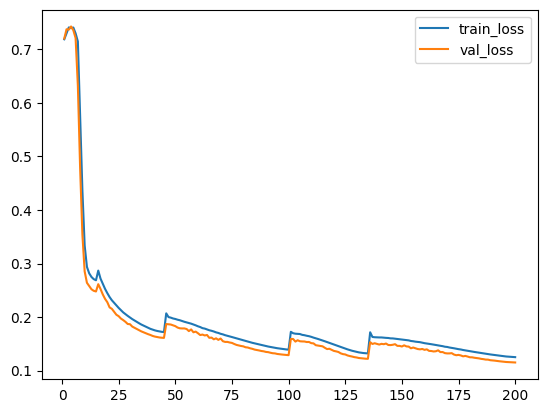

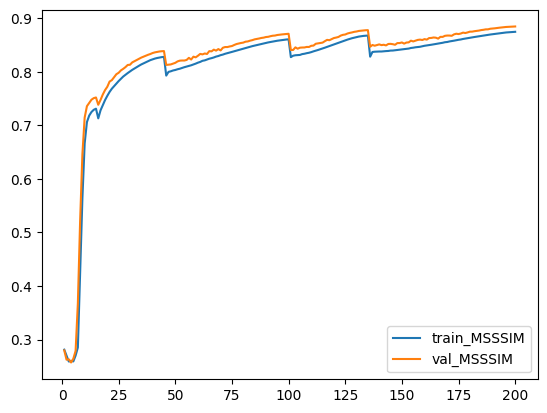

In [9]:
with open('acc_loss.bin', 'rb') as file:
    l = pickle.load(file)
    
l1 = dict(list(l[0].items())[0:100])
l2 = dict(list(l[1].items())[0:100])


train_loss = l[0]['train']
val_loss = l[0]['val']
train_acc = l[1]['train']
val_acc = l[1]['val']
epochs = [i+1 for i in range(200)]

plt.figure()
plt.plot(epochs, train_loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()

plt.figure()
plt.plot(epochs, train_acc, label='train_MSSSIM')
plt.plot(epochs, val_acc, label='val_MSSSIM')
plt.legend()


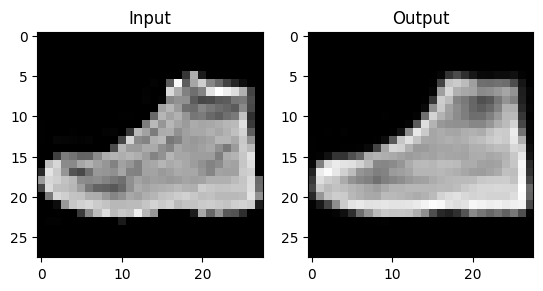

In [ ]:
import random


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Autoencoder().to(device)
model.load_state_dict(torch.load('autoencoder_wts_out.pth', map_location=device))
model.eval()

images, _ = next(iter(test_loader))
random_idx = random.randint(0, len(images) - 1)
input_tensor = images[random_idx].unsqueeze(0).to(device)
with torch.no_grad():
    output_tensor = model(input_tensor)

#matplotlib cant work with gpus and require a different dim
input_img = input_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
output_img = output_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()


plt.subplot(1, 2, 1)
plt.title("Input")
plt.imshow(input_img.squeeze(), cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Output")
plt.imshow(output_img.squeeze(), cmap='gray')

plt.show()